In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1]
sys.path.append(str(PROJECT_ROOT))

In [2]:
from loaders._load_vn30_reg import preprocess, VN30, TARGETS
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_percentage_error

In [3]:
_ = preprocess("ACB", verbose=True)

=== Preprocessing ACB ===
Feature shapes in train: (1215, 120), val: (0, 120), test: (298, 120)
Target shapes in train: (1215, 4), val: (0, 4), test: (298, 4)


In [4]:
for symbol in VN30:
    data = preprocess(symbol)
    X_train, Y_train = data['train']
    X_val, Y_val = data['val']
    X_test, Y_test = data['test']
    target_scaler = data['scaler']['target']

    model = LinearRegression()
    model.fit(X_train, Y_train)

    Y_pred = model.predict(X_test)
    Y_pred = target_scaler.inverse_transform(Y_pred)
    Y_test = target_scaler.inverse_transform(Y_test)

    r2 = r2_score(Y_test, Y_pred)
    mape = mean_absolute_percentage_error(Y_test, Y_pred) * 100

    print(f"Symbol: {symbol}, R^2: {r2:.4f}, MAPE: {mape:.4f}")

Symbol: ACB, R^2: 0.9356, MAPE: 0.6922
Symbol: BCM, R^2: 0.9661, MAPE: 1.1357
Symbol: BID, R^2: 0.9339, MAPE: 0.8719
Symbol: BVH, R^2: 0.9820, MAPE: 0.9549
Symbol: CTG, R^2: 0.9698, MAPE: 0.9413Symbol: CTG, R^2: 0.9698, MAPE: 0.9413
Symbol: FPT, R^2: 0.9879, MAPE: 1.0156
Symbol: GAS, R^2: 0.9681, MAPE: 0.6738
Symbol: GVR, R^2: 0.9531, MAPE: 1.4148
Symbol: HDB, R^2: 0.9739, MAPE: 0.9433

Symbol: FPT, R^2: 0.9879, MAPE: 1.0156
Symbol: GAS, R^2: 0.9681, MAPE: 0.6738
Symbol: GVR, R^2: 0.9531, MAPE: 1.4148
Symbol: HDB, R^2: 0.9739, MAPE: 0.9433
Symbol: HPG, R^2: 0.9174, MAPE: 0.9013
Symbol: LPB, R^2: 0.9957, MAPE: 1.0607
Symbol: MBB, R^2: 0.9556, MAPE: 0.8822
Symbol: MSN, R^2: 0.9641, MAPE: 0.9728
Symbol: MWG, R^2: 0.9791, MAPE: 1.0745
Symbol: HPG, R^2: 0.9174, MAPE: 0.9013
Symbol: LPB, R^2: 0.9957, MAPE: 1.0607
Symbol: MBB, R^2: 0.9556, MAPE: 0.8822
Symbol: MSN, R^2: 0.9641, MAPE: 0.9728
Symbol: MWG, R^2: 0.9791, MAPE: 1.0745
Symbol: PLX, R^2: 0.9813, MAPE: 0.9772
Symbol: SAB, R^2: 0.9477,

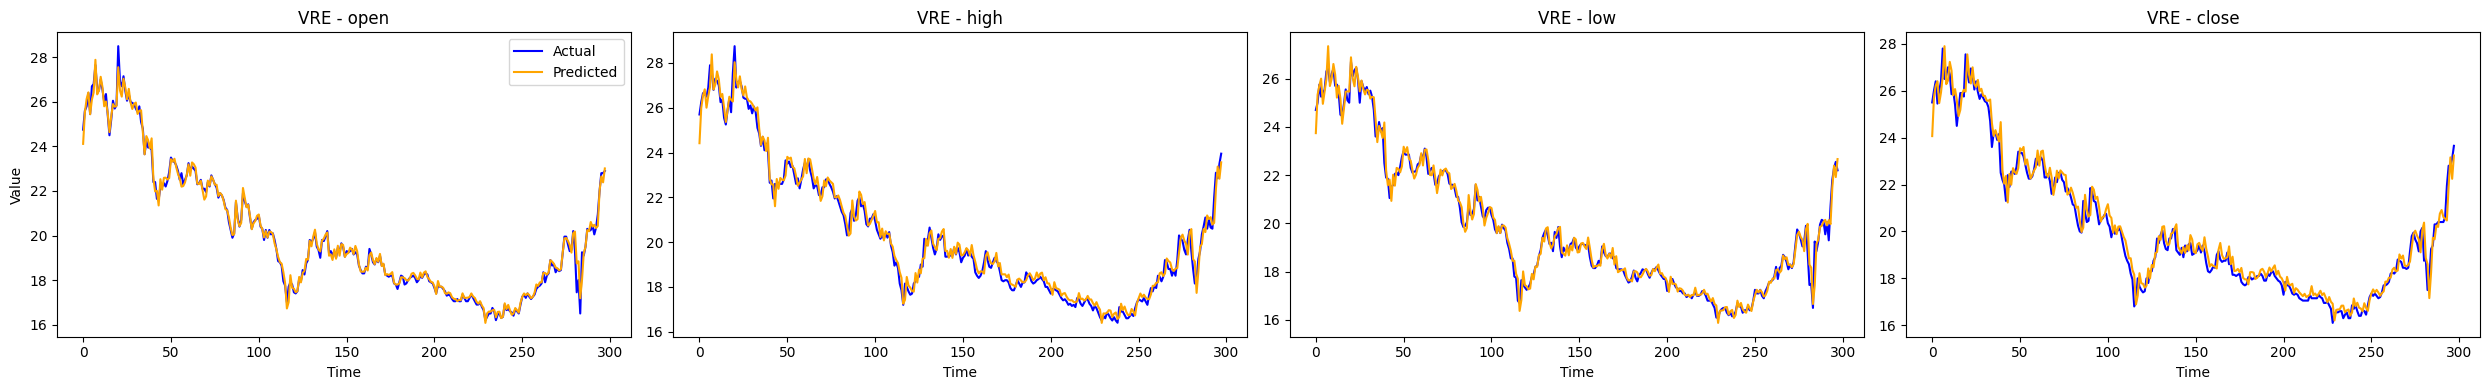

In [5]:
import matplotlib.pyplot as plt

# 4 subplots nằm ngang: 1 hàng x 4 cột
fig, axes = plt.subplots(1, 4, figsize=(25, 4), sharex=True)    

for i, name in enumerate(TARGETS):
    ax = axes[i]
    ax.plot(Y_test[:, i], label='Actual', color='blue')
    ax.plot(Y_pred[:, i], label='Predicted', color='orange')
    ax.set_title(f"{symbol} - {name}")
    ax.set_xlabel("Time")
    if i == 0:
        ax.set_ylabel("Value")
        ax.legend()

plt.tight_layout()
plt.show()      